# Quick Start: TS-Debate (Ours)

Demo: One sample per task across ALL 20 tasks.

**TS-Debate Framework (Multi-Modal Evidence Synthesis):**
- Modality agents (TEXT, VISUAL, NUMERICAL) present EVIDENCE (not answers)
- Non-adversarial: Each modality presents observations & inferences
- Judges score EVIDENCE QUALITY (accuracy, logic, honesty)
- Weighted synthesis: All modalities contribute proportionally to their evidence scores
- Unified run_debate() API


In [11]:
# Setup: Load environment
from dotenv import load_dotenv

_ = load_dotenv()

In [12]:
# Setup: Imports
import base64
from IPython.display import display, Image

from ts_debate.ts_debate import TSDebate
from data_loaders import MTBenchDataLoader, TimerBedLoader, TSQALoader
from utils.task_config import prepare_context
from utils.cost_monitor import CostMonitor

# Helper to display base64 charts
def show_chart(b64_str, title="Chart"):
    """Display a base64-encoded chart image."""
    if b64_str:
        _ = display(Image(data=base64.b64decode(b64_str), width=480))

In [13]:
# Setup: Initialize TS-Debate (Multi-Modal Evidence Synthesis)
monitor = CostMonitor()

evaluator = TSDebate(
    provider="openrouter",
    model="openai/gpt-4.1-mini",
    monitor=monitor,  # Track cost and time per stage
    num_judges=3,
    max_rounds=2,
    max_judge_rounds=1,
    verbose=True)

🔬 TS-Debate (Evidence Synthesis) initialized: 3 modalities, 2 round(s), 3 judges, KE: ✓


---
## MTBench Finance Tasks (5 tasks)


In [14]:
loader = MTBenchDataLoader(domain='finance')

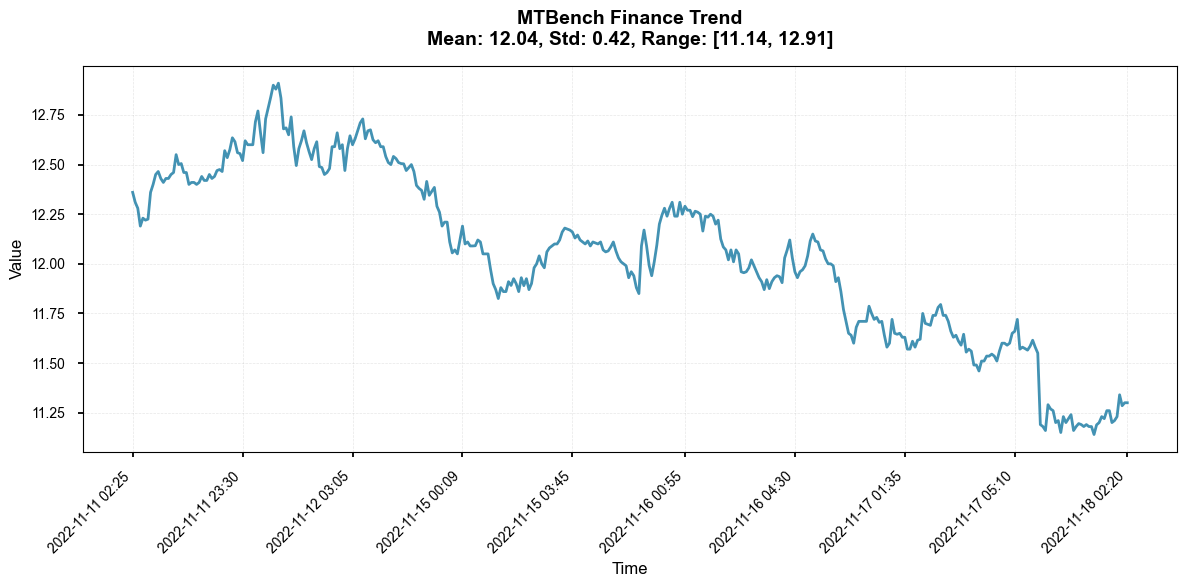

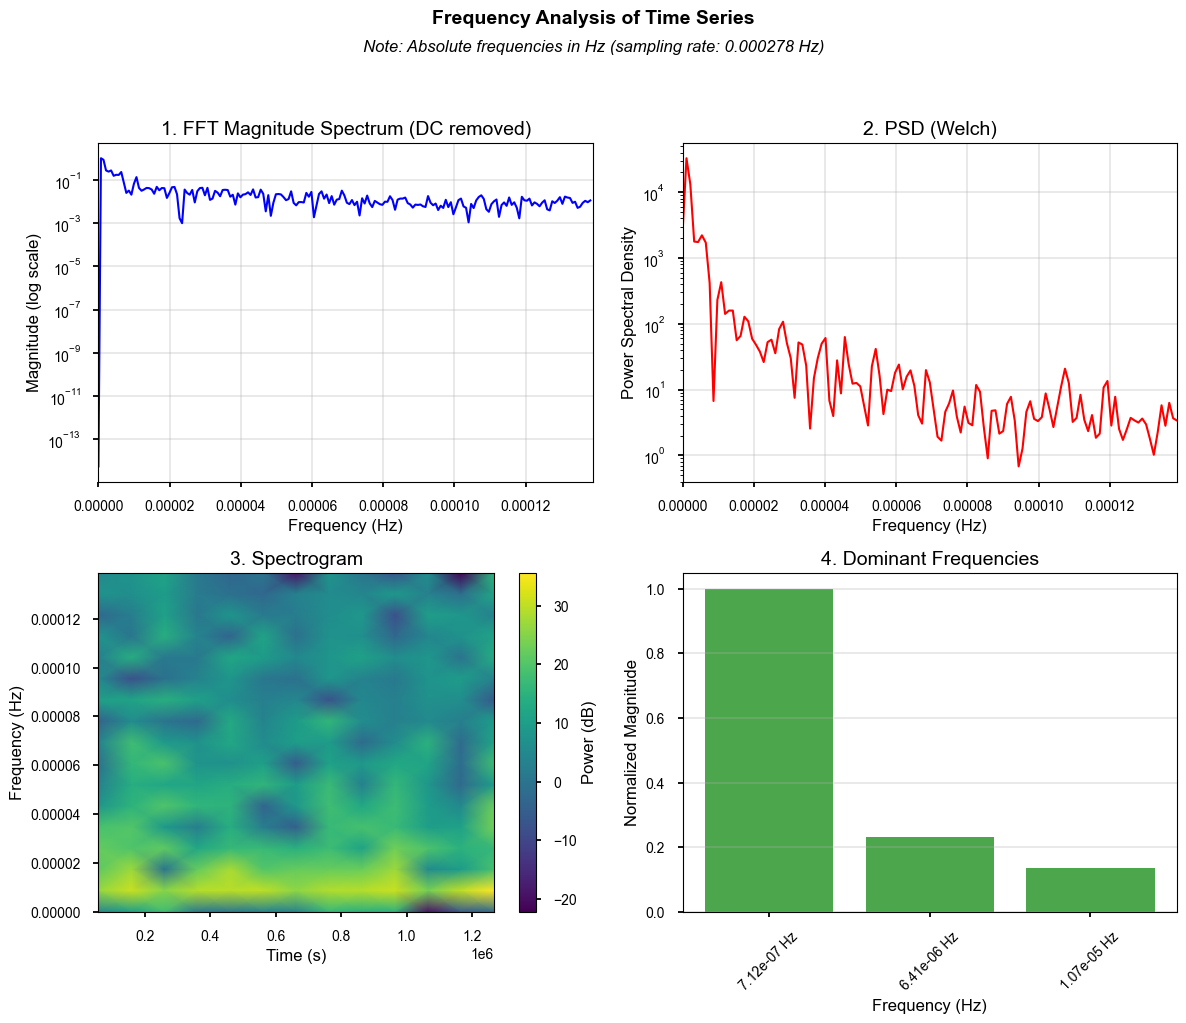

Task: mtbench_finance_trend
Options: ['<-4%', '-2% ~ -4%', '-2% ~ +2%', '+2% ~ +4%', '>+4%']

KNOWLEDGE ELICITATION

DOMAIN:  
Financial time-series forecasting and classification task — specifically, short-term stock price trend prediction categorized into discrete percentage change bins (classification).

KNOWLEDGE:  
- Stock prices are influenced by a combination of historical price patterns, volume, volatility, and external factors such as news sentiment and earnings estimate revisions.  
- Typical hourly stock price changes are often small, usually within ±1% to ±3% per hour for liquid stocks, but can accumulate to larger moves over days or weeks.  
- Earnings estimate revisions are a strong leading indicator: upward revisions often precede positive price trends, while downward revisions can signal declines.  
- The Zacks Rank system is a well-known quantitative model that correlates earnings estimate revisions with future stock returns; stocks rated #1 or #2 historically outperfo

In [15]:
# Task 1: MTBench Finance - Trend
sample = loader.load_task('trend')[0]
context = prepare_context(sample, 'trend', 'MTBench Finance Trend', benchmark='MTBench', domain='finance')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Finance Trend")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Finance Trend")

print(f'Task: mtbench_finance_trend')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 2: MTBench Finance - Forecasting
sample = loader.load_task('forecasting')[0]
context = prepare_context(sample, 'forecasting', 'MTBench Finance Forecasting', benchmark='MTBench', domain='finance')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Finance Forecasting")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Finance Forecasting")

print(f'Task: mtbench_finance_forecasting')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 3: MTBench Finance - Indicator
sample = loader.load_task('indicator_macd')[0]
context = prepare_context(sample, 'indicator', 'MTBench Finance MACD', benchmark='MTBench', domain='finance')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Finance Indicator")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Finance Indicator")

print(f'Task: mtbench_finance_indicator')
response, _  = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 4: MTBench Finance - Correlation
sample = loader.load_task('correlation', setting='long')[0]
context = prepare_context(sample, 'correlation', 'MTBench Finance Correlation', benchmark='MTBench', domain='finance')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Finance Correlation")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Finance Correlation")

print(f'Task: mtbench_finance_correlation')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 5: MTBench Finance - MCQA
sample = loader.load_task('mcqa', setting='long')[0]
context = prepare_context(sample, 'mcqa', 'MTBench Finance MCQA', benchmark='MTBench', domain='finance')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Finance MCQA")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Finance MCQA")

print(f'Task: mtbench_finance_mcqa')
print(f'Question: {context["question"]}')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

---
## MTBench Weather Tasks (4 tasks)


In [ ]:
loader = MTBenchDataLoader(domain='weather')

In [ ]:
# Task 6: MTBench Weather - Trend
sample = loader.load_task('trend')[0]
context = prepare_context(sample, 'trend', 'MTBench Weather Trend', benchmark='MTBench', domain='weather')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Weather Trend")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Weather Trend")

print(f'Task: mtbench_weather_trend')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 7: MTBench Weather - Forecasting
sample = loader.load_task('forecasting')[0]
context = prepare_context(sample, 'forecasting', 'MTBench Weather Forecasting', benchmark='MTBench', domain='weather')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Weather Forecasting")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Weather Forecasting")

print(f'Task: mtbench_weather_forecasting')
response, _ = evaluator.run_debate(sample['task_instruction'], context)


In [ ]:
# Task 8: MTBench Weather - Indicator
sample = loader.load_task('indicator_macd')[0]
context = prepare_context(sample, 'indicator', 'MTBench Weather Indicator', benchmark='MTBench', domain='weather')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Weather Indicator")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Weather Indicator")

print(f'Task: mtbench_weather_indicator')
response, _ = evaluator.run_debate(sample['task_instruction'], context)
print(f'\n📝 Response: {response.final_decision}')


In [ ]:
# Task 9: MTBench Weather - MCQA
sample = loader.load_task('mcqa', setting='long')[0]
context = prepare_context(sample, 'mcqa', 'MTBench Weather MCQA', benchmark='MTBench', domain='weather')

show_chart(context['time_series_chart'], f"Time Series Chart: MTBench Weather MCQA")
show_chart(context['frequency_chart'], f"Frequency Chart: MTBench Weather MCQA")

print(f'Task: mtbench_weather_mcqa')
print(f'Question: {context["question"]}')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

---
## TimerBed Tasks (6 tasks)


In [ ]:
loader = TimerBedLoader()

In [ ]:
# Task 10: TimerBed - HAR
sample = loader.load_dataset('HAR')['test'][0]
context = prepare_context(sample, 'classification', 'TimerBed HAR', benchmark='TimerBed')

show_chart(context['time_series_chart'], f"Time Series Chart: TimerBed HAR")
show_chart(context['frequency_chart'], f"Frequency Chart: TimerBed HAR")

print(f'Task: timerbed_har')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 11: TimerBed - ECG
sample = loader.load_dataset('ECG')['test'][0]
context = prepare_context(sample, 'classification', 'TimerBed ECG', benchmark='TimerBed')

show_chart(context['time_series_chart'], f"Time Series Chart: TimerBed ECG")
show_chart(context['frequency_chart'], f"Frequency Chart: TimerBed ECG")

print(f'Task: timerbed_ecg')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 12: TimerBed - CTU
sample = loader.load_dataset('CTU')['test'][0]
context = prepare_context(sample, 'classification', 'TimerBed CTU', benchmark='TimerBed')

show_chart(context['time_series_chart'], f"Time Series Chart: TimerBed CTU")
show_chart(context['frequency_chart'], f"Frequency Chart: TimerBed CTU")

print(f'Task: timerbed_ctu')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)
print(f'\n📝 Response: {response.final_decision}')


In [ ]:
# Task 13: TimerBed - EMG
sample = loader.load_dataset('EMG')['test'][0]
context = prepare_context(sample, 'classification', 'TimerBed EMG', benchmark='TimerBed')

show_chart(context['time_series_chart'], f"Time Series Chart: TimerBed EMG")
show_chart(context['frequency_chart'], f"Frequency Chart: TimerBed EMG")

print(f'Task: timerbed_emg')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 14: TimerBed - RCW
sample = loader.load_dataset('RCW')['test'][0]
context = prepare_context(sample, 'classification', 'TimerBed RCW', benchmark='TimerBed')

show_chart(context['time_series_chart'], f"Time Series Chart: TimerBed RCW")
show_chart(context['frequency_chart'], f"Frequency Chart: TimerBed RCW")

print(f'Task: timerbed_rcw')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)
print(f'\n📝 Response: {response.final_decision}')


In [ ]:
# Task 15: TimerBed - TEE
sample = loader.load_dataset('TEE')['test'][0]
context = prepare_context(sample, 'classification', 'TimerBed TEE', benchmark='TimerBed')

show_chart(context['time_series_chart'], f"Time Series Chart: TimerBed TEE")
show_chart(context['frequency_chart'], f"Frequency Chart: TimerBed TEE")

print(f'Task: timerbed_tee')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)
print(f'\n📝 Response: {response.final_decision}')


---
## TSQA Tasks (5 tasks)


In [ ]:
loader = TSQALoader()

In [ ]:
# Task 16: TSQA - Classification
sample = loader.load_task('classification')[0]
context = prepare_context(sample, 'classification', 'TSQA Classification', benchmark='TSQA')

show_chart(context['time_series_chart'], f"Time Series Chart: TSQA Classification")
show_chart(context['frequency_chart'], f"Frequency Chart: TSQA Classification")

print(f'Task: tsqa_classification')
print(f'Options: {context["options"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 17: TSQA - Anomaly
sample = loader.load_task('anomaly')[0]
context = prepare_context(sample, 'anomaly', 'TSQA Anomaly', benchmark='TSQA')

show_chart(context['time_series_chart'], f"Time Series Chart: TSQA Anomaly")
show_chart(context['frequency_chart'], f"Frequency Chart: TSQA Anomaly")

print(f'Task: tsqa_anomaly')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 18: TSQA - Forecasting
sample = loader.load_task('forecasting')[0]
context = prepare_context(sample, 'forecasting', 'TSQA Forecasting', benchmark='TSQA')

show_chart(context['time_series_chart'], f"Time Series Chart: TSQA Forecasting")
show_chart(context['frequency_chart'], f"Frequency Chart: TSQA Forecasting")

print(f'Task: tsqa_forecasting')
response, _ = evaluator.run_debate(sample['task_instruction'], context)
print(f'\n📝 Response: {response.final_decision}')


In [ ]:
# Task 19: TSQA - Imputation
sample = loader.load_task('imputation')[0]
context = prepare_context(sample, 'imputation', 'TSQA Imputation', benchmark='TSQA')

show_chart(context['time_series_chart'], f"Time Series Chart: TSQA Imputation")
show_chart(context['frequency_chart'], f"Frequency Chart: TSQA Imputation")

print(f'Task: tsqa_imputation')
response, _ = evaluator.run_debate(sample['task_instruction'], context)

In [ ]:
# Task 20: TSQA - QA
sample = loader.load_task('qa')[0]
context = prepare_context(sample, 'qa', 'TSQA QA', benchmark='TSQA')

show_chart(context['time_series_chart'], f"Time Series Chart: TSQA QA")
show_chart(context['frequency_chart'], f"Frequency Chart: TSQA QA")

print(f'Task: tsqa_qa')
print(f'Question: {context["question"]}')
response, _ = evaluator.run_debate(sample['task_instruction'], context)